In [1]:
# This is what I'm gonna need for the wavelet transform
import sys
sys.path.append("/home/r/Robert.Reichert/juwavelet")
import juwavelet.transform as transform
from juwavelet import utils
sys.path.append('/home/r/Robert.Reichert/WAVEGUIDE_campaign/k_retrieval')
import k_retrieval.utils_MF as MF

# This is for the data preprocessing and the segmentation
sys.path.append('../scripts')
import utils_2d_v3 as two
import plot_tools as pt
import utils_AWE as awe

import xarray as xr
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import copy
import time

plt.style.use("../latex_default_AMT.mplstyle")

In [2]:
def sphere_wave(X, Y, x0, y0, lh):
    """
    Computes a spherical wave

    Parameters
    ----------
    X, Y : arrays of x- and y-coordinates
    x0, y0 : ints of x- and y-offests
    lh : float defining the wavelength
    """

    k = 2 * np.pi / lh
    signal = np.cos(k * np.sqrt((X - x0) ** 2 + (Y - y0) ** 2)) * \
        (np.exp(-(X - x0)**2 / (4 * lh**2) - (Y - y0)**2 / (4 * lh**2)) ** 0.5)

    return signal

def wavepaket(X, Y, x0, y0, sx, sy, lh, theta):
    """
    Computes a Gaussian wave paket

    Parameters
    ----------
    X, Y : arrays of x- and y-coordinates
    x0, y0 : ints of x- and y-offests
    sx, sy : floats defining the width of the Gaussian
    lh : float defining the wavelength
    theta: float defining the orientation (clockwise from 12o'clock)
    """

    kx = 2 * np.pi / lh * np.sin(theta)
    ky = 2 * np.pi / lh * np.cos(theta)
    oscillation = np.cos(kx * (X - x0) + ky * (Y - y0))
    envelope = np.exp(-(X - x0)**2 / (2 * sx**2) - (Y - y0)**2 / (2 * sy**2))

    return oscillation * envelope

In [26]:
x = np.linspace(0, 100, 201)
y = np.linspace(0, 100, 201)
dx, dy = 0.5, 0.5
nx, ny = 201, 201

X, Y = np.meshgrid(x, y)

x0 = [50, 60, 30, 70, 80, 25, 65, 22]
y0 = [50, 70, 60, 40, 80, 80, 20, 22]
lh0 = [6, 3, 8, 14, 13, 20, 25, 5]
th0 = [60,0,110,10,110,160,20,np.nan]

wp_1 = wavepaket(X, Y, 50, 50, 3*7, 3*10, 6, np.deg2rad(120))
wp_2 = wavepaket(X, Y, 60, 70, 3*4, 3*4, 3, np.deg2rad(0))
wp_3 = wavepaket(X, Y, 30, 60, 3*20, 3*5, 8, np.deg2rad(110))
wp_4 = wavepaket(X, Y, 70, 40, 3*10, 3*10, 14, np.deg2rad(10))
wp_5 = wavepaket(X, Y, 80, 80, 3*15, 3*15, 13, np.deg2rad(110))
wp_6 = wavepaket(X, Y, 25, 80, 3*20, 3*5, 20, np.deg2rad(160))
wp_7 = wavepaket(X, Y, 65, 20, 3*20, 3*5, 25, np.deg2rad(20))
wp_8 = 2*sphere_wave(X, Y, 22, 22, 5)
white_noise = np.random.normal(0,0.1,(nx,ny))

#signal = wp_1 + wp_2 + wp_3 + wp_4 + wp_5 + wp_6 + wp_7 + wp_8 + white_noise
signal = wp_1 + wp_8 + white_noise

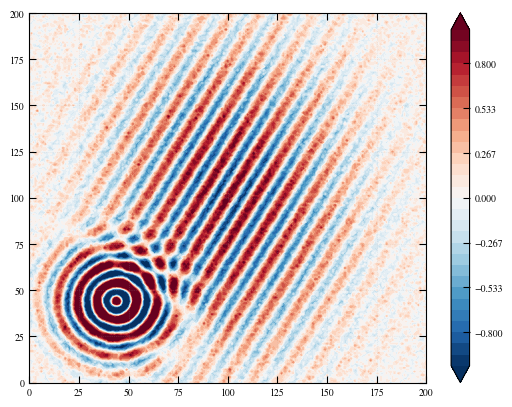

In [27]:
plt.contourf(signal,levels=np.linspace(-1,1,31),cmap='RdBu_r',extend='both')
plt.colorbar()

In [28]:
# Prepare the data for wavelet transform
orig = signal.copy()
BI_high, BI_low = two.BG_removal(orig)

nmask  = orig.shape
ntap   = int(0.1*np.min(nmask))
signal = utils.smooth_edges(BI_high, ntap, window='tukey')

In [29]:
s0 = 4 #smallest scale that we wanna resolve
s1 = 0.5 * min([nx,ny]) #largest scale we wanna resolve (since the first Fourier component is part of the background (BI_low) the largest scale fits twice in the domain)
dj = 1 / 8 # apäter wieder dj=1/8
js = int(1/dj*np.log2(s1/s0))
jt = 21
print('Decomposition shape will be: ', js, jt, nx, ny)

cwt_result = transform.decompose2d(signal,dx,dy,s0*min([dx,dy]),dj,js,jt,aspect=1,nxpad=None,nypad=None,opts={'param': 2*np.pi},mode="scaled",dtype=np.complex128)

print(f"The data resolution is {dx:.0f} km and the smallest wavelength you analyze is {cwt_result['period'][0]:.0f} km.")
print(f"The data domain is at least {min([nx,ny])*dx:.0f} km and the largest wavelength you analyze is {cwt_result['period'][-1]:.0f} km.")

Decomposition shape will be:  37 21 201 201
The data resolution is 0 km and the smallest wavelength you analyze is 2 km.
The data domain is at least 100 km and the largest wavelength you analyze is 45 km.


In [30]:
WAS        = np.abs(cwt_result['decomposition'])
WAS_normed = two.norm_WAS(WAS)

start_time = time.time()
seg_v1 = two.wavefield_segmentation_2d(WAS_normed,3,connectivity=1)
print("--- %s seconds ---" % (time.time() - start_time))
print('Identified', np.max(seg_v1), 'initial wave packets!')

k  = 2 * np.pi / cwt_result["period"]

start_time = time.time()
eps = np.abs(np.diff(np.log(k)))[0]*np.sqrt(2)
labels, cluster_labels = two.find_clusters_logk_theta(cwt_result, seg_v1, eps=eps)
cluster_map    = two.build_cluster_map_with_noise(labels,cluster_labels)
seg_v2         = two.relabel_by_xy_overlap(seg_v1, cluster_map)
print("--- %s seconds ---" % (time.time() - start_time))
print('Number of wave packets after Clustering', np.max(seg_v2))

--- 59.11185836791992 seconds ---
Identified 2 initial wave packets!
suggested scaling: 0.5791684504007105
--- 0.3281111717224121 seconds ---
Number of wave packets after Clustering 2


Text(0.5, 1.0, 'Variance Filtering')

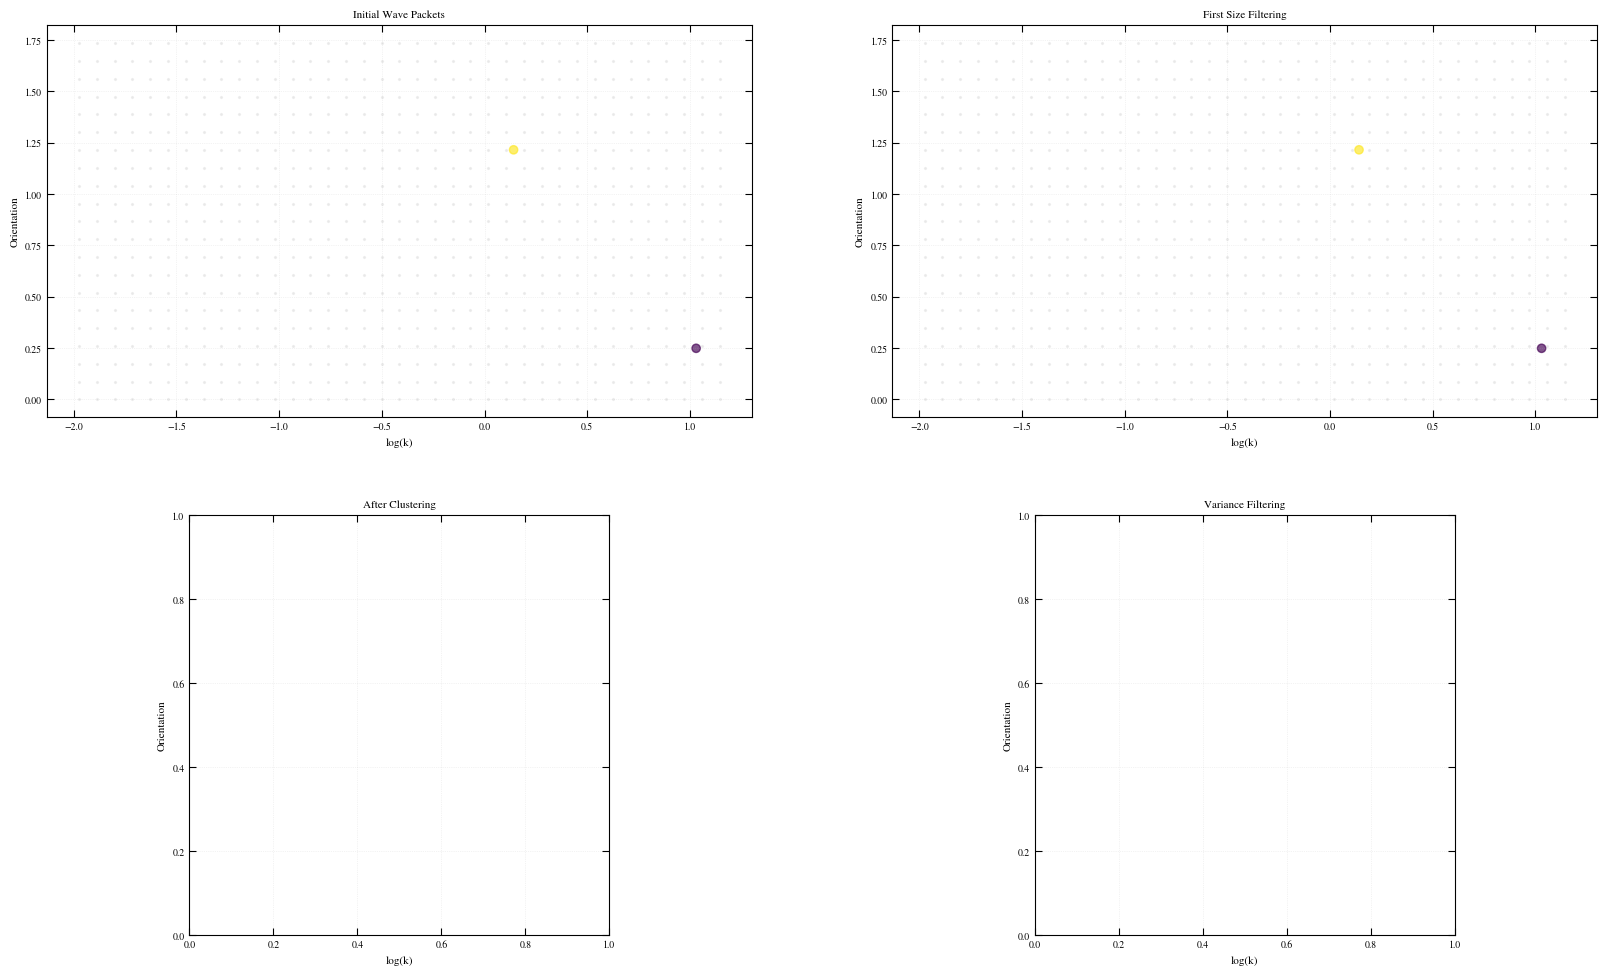

In [34]:
k  = 2 * np.pi / cwt_result["period"]
orientation = cwt_result['theta']

labels_1, amp_seg_1, kx_seg_1, ky_seg_1, k_seg_1, theta_seg_1 = two.segments2points_pi_periodic(WAS, k, orientation, seg_v1)
labels_2, amp_seg_2, kx_seg_2, ky_seg_2, k_seg_2, theta_seg_2 = two.segments2points_pi_periodic(WAS, k, orientation, seg_v2)

scaling=0.58

fig = plt.figure(figsize=(20,12))
ax1=fig.add_subplot(221)
ax2=fig.add_subplot(222)
ax3=fig.add_subplot(223)
ax4=fig.add_subplot(224)

# Grid
for ia in k:
    for ib in orientation:
        ax1.scatter(np.log(ia),scaling*ib,color='grey',alpha=0.1,s=2)
        ax2.scatter(np.log(ia),scaling*ib,color='grey',alpha=0.1,s=2)
        #ax3.scatter(np.log(ia),scaling*ib,color='grey',alpha=0.1,s=2)
        #ax4.scatter(np.log(ia),scaling*ib,color='grey',alpha=0.1,s=2)

# ALL initial wavepackets
vmax = np.percentile(amp_seg_1,95)

ax1.scatter(np.log(k_seg_1),scaling*theta_seg_1,c=amp_seg_1,alpha=0.67,vmin=0,vmax=vmax)
ax2.scatter(np.log(k_seg_2),scaling*theta_seg_2,c=amp_seg_2,alpha=0.67,vmin=0,vmax=vmax)
#ax3.scatter(np.log(k_seg_3),scaling*theta_seg_3,c=amp_seg_3,alpha=0.67,vmin=0,vmax=vmax)
#ax4.scatter(np.log(k_seg_4),scaling*theta_seg_4,c=amp_seg_4,alpha=0.67,vmin=0,vmax=vmax)

ax1.set_aspect("equal", adjustable="box")
ax1.set_xlabel('log(k)')
ax1.set_ylabel('Orientation')
ax1.set_title('Initial Wave Packets')

ax2.set_aspect("equal", adjustable="box")
ax2.set_xlabel('log(k)')
ax2.set_ylabel('Orientation')
ax2.set_title('First Size Filtering')

ax3.set_aspect("equal", adjustable="box")
ax3.set_xlabel('log(k)')
ax3.set_ylabel('Orientation')
ax3.set_title('After Clustering')

ax4.set_aspect("equal", adjustable="box")
ax4.set_xlabel('log(k)')
ax4.set_ylabel('Orientation')
ax4.set_title('Variance Filtering')

In [31]:
recon_WP, amp_WP, kx_WP, ky_WP = two.recon_allWP_2d(cwt_result, seg_v2)

100%|██████████| 40401/40401 [00:02<00:00, 17623.04it/s]


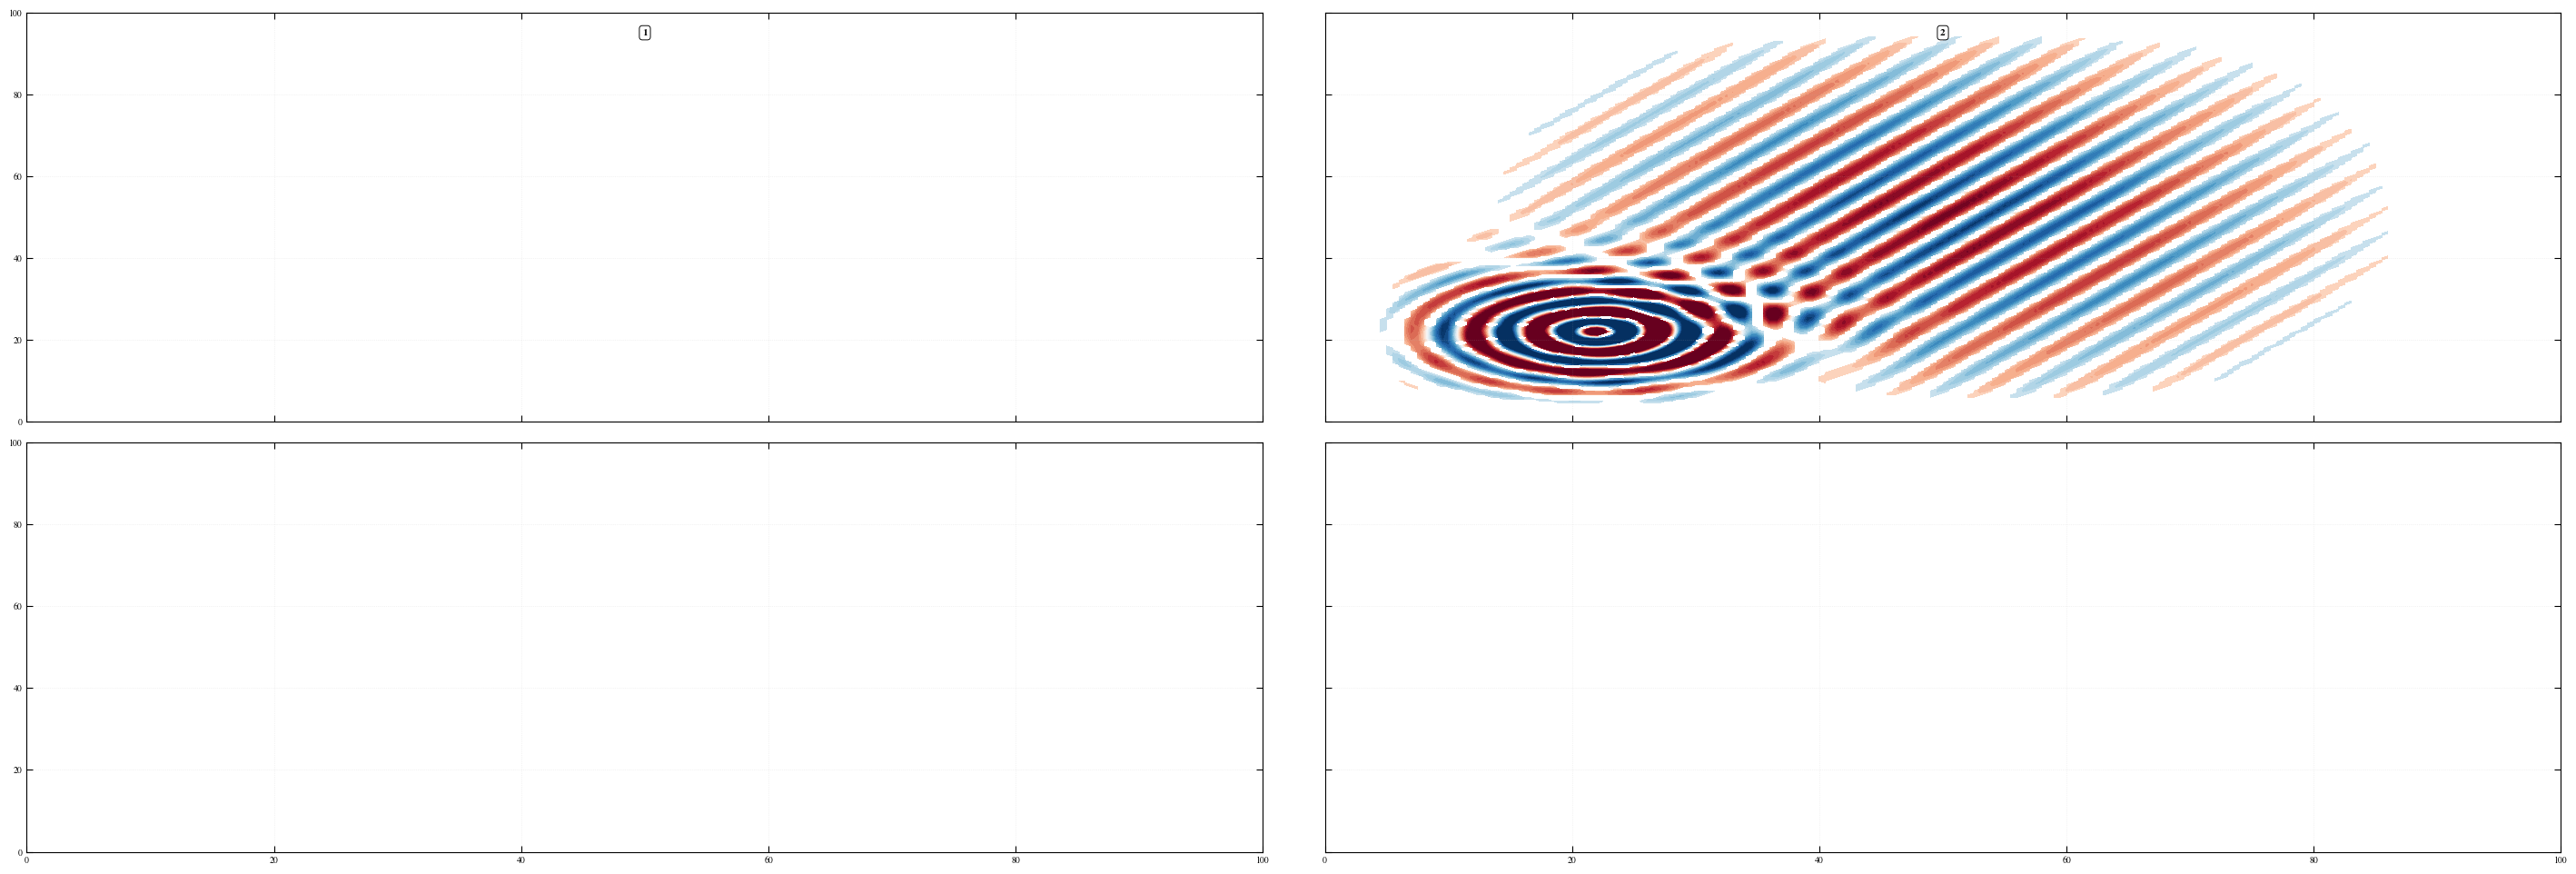

In [33]:
#Mit dj = 1/8 / sMAD_threshold = 3 / prominence=3 / sMAD_threshold=3 / eps=0.18 / dj = 1/8
import matplotlib.colors as mcolors
rad_lev=np.linspace(-1,1,31)
row, col = 2,2#pt.define_figgrid(recon_WP.shape[0])
gskw = {"hspace": 0.05, "wspace": 0.05, "width_ratios": col*[1], "height_ratios": row*[1]}

fig, ax=plt.subplots(row,col, figsize=(36,12), gridspec_kw=gskw,sharex=True, sharey=True)

for i in range(row):
    for j in range(col):
        if i*col+j < recon_WP.shape[0]:
            masked = np.ma.masked_inside(recon_WP[i*col+j,:,:], -0.2, 0.2)  
            norm = mcolors.TwoSlopeNorm(vmin=rad_lev[0], vcenter=0.0, vmax=rad_lev[-1])
            ax[i,j].contourf(x,y,masked,levels=rad_lev,cmap="RdBu_r",norm=norm,extend='both')
            ax[i,j].text(0.5, 0.95, str(i*col+j+1), verticalalignment='center', horizontalalignment='center', transform=ax[i,j].transAxes, 
                                    weight='bold', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})

In [35]:
cwt_result['period']

array([ 2.        ,  2.18101547,  2.37841423,  2.59367911,  2.82842712,
        3.08442165,  3.36358566,  3.66801617,  4.        ,  4.36203093,
        4.75682846,  5.18735822,  5.65685425,  6.1688433 ,  6.72717132,
        7.33603235,  8.        ,  8.72406186,  9.51365692, 10.37471644,
       11.3137085 , 12.3376866 , 13.45434264, 14.67206469, 16.        ,
       17.44812372, 19.02731384, 20.74943287, 22.627417  , 24.67537321,
       26.90868529, 29.34412938, 32.        , 34.89624745, 38.05462768,
       41.49886575, 45.254834  ])

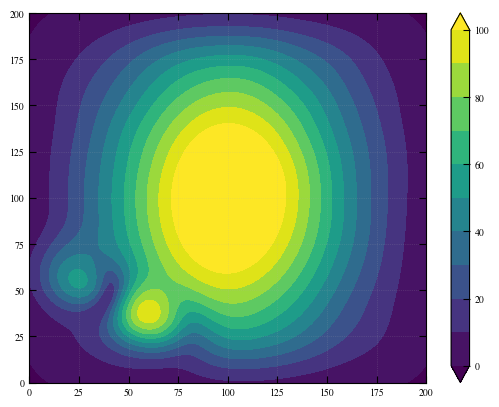

In [48]:
plt.contourf(WAS_normed[12,14,:,:],levels=np.linspace(0,100,11),extend='both')
plt.colorbar()

In [28]:
# Denoising
noise_floor = 4*0.1 #units of BI
wavy_stuff = two.denoise_2d(cwt_result,white_noise_level=noise_floor)

initial noise 0.10040051575195565
derived noise 0.1003901126730108


Text(0.03, 0.94, 'c')

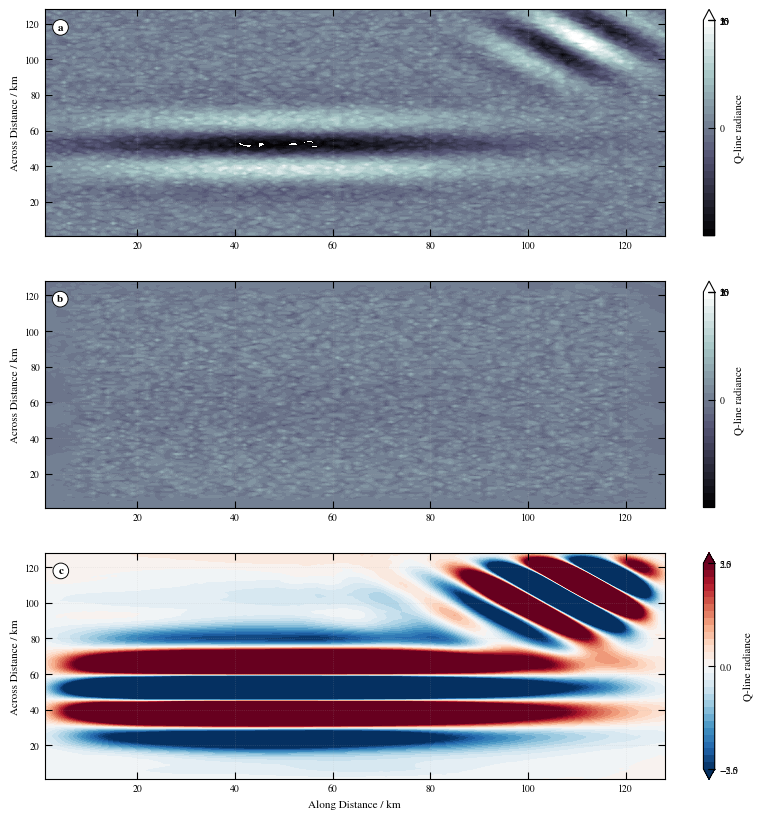

In [29]:
BI_lev = np.linspace(-1,1,31)
fig = plt.figure(figsize=(10,10))
ax1 = fig.add_subplot(311)
plot_orig = ax1.contourf(x,y,orig,levels=BI_lev,extend='max',cmap='bone')
cbar = fig.colorbar(plot_orig,ticks=[0,5,10,15,20],label='Q-line radiance')

ax2 = fig.add_subplot(312)
plot_dirt = ax2.contourf(x,y,BI_low+signal-wavy_stuff+np.mean(orig),levels=BI_lev,extend='max',cmap='bone')
cbar = fig.colorbar(plot_dirt,ticks=[0,5,10,15,20],label='Q-line radiance')

ax3 = fig.add_subplot(313)
plot_wave = ax3.contourf(x,y,wavy_stuff,levels=np.linspace(-0.1,0.1,31),extend='both',cmap='RdBu_r')
cbar = fig.colorbar(plot_wave,ticks=[-5,-2.5,0,2.5,5],label='Q-line radiance')

print('initial noise', np.std(white_noise))
print('derived noise', np.std(signal[13:-13,13:-13]-wavy_stuff[13:-13,13:-13]))

ax3.set_xlabel('Along Distance / km')
ax1.set_ylabel('Across Distance / km')
ax2.set_ylabel('Across Distance / km')
ax3.set_ylabel('Across Distance / km')

letterbox = {"boxstyle": "circle","lw": 0.67,"facecolor": "white","edgecolor": "black"}
ax1.text(0.03,0.94,'a',transform=ax1.transAxes, bbox=letterbox, verticalalignment="top", horizontalalignment="right", weight="bold") 
ax2.text(0.03,0.94,'b',transform=ax2.transAxes, bbox=letterbox, verticalalignment="top", horizontalalignment="right", weight="bold") 
ax3.text(0.03,0.94,'c',transform=ax3.transAxes, bbox=letterbox, verticalalignment="top", horizontalalignment="right", weight="bold") 

#plt.savefig('./figures/2D_example_AWE_BG_removal.png',dpi=300,bbox_inches="tight",pad_inches=0.02)

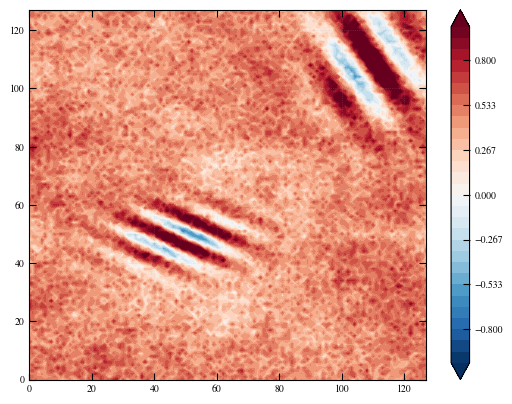

In [40]:
# white Noise + Red Noise
dx, dy = 1, 1
nx, ny = 128, 128
x = np.linspace(dx,nx*dx,nx)
y = np.linspace(dy,ny*dy,ny)
X, Y = np.meshgrid(x,y)
white_noise = np.random.normal(0,0.1,(nx,ny))

noise_amp = 0.5
l_0 = 100 #[km] largest scale

red_noise = MF.generateRandomScreen(dx, dy, nx, ny, noise_amp, l_0)

wave_1 = np.sin(2*np.pi/20*X+2*np.pi/10*Y)*np.exp(-(X-50)**2/(2*10)**2-(Y-50)**2/(2*5)**2)
wave_2 = np.sin(2*np.pi/20*X+2*np.pi/30*Y)*np.exp(-(X-110)**2/(2*8)**2-(Y-110)**2/(2*10)**2)
signal = wave_1+wave_2+white_noise+red_noise

plt.contourf(signal,levels=np.linspace(-1,1,31),cmap='RdBu_r',extend='both')
plt.colorbar()

In [41]:
# Prepare the data for wavelet transform
orig = signal.copy()
BI_high, BI_low = two.BG_removal(orig,max_order=1)

nmask  = orig.shape
ntap   = int(0.1*np.min(nmask))
signal = utils.smooth_edges(BI_high, ntap, window='tukey')

In [42]:
s0 = 4 #smallest scale that we wanna resolve
s1 = 0.5 * min([nx,ny]) #largest scale we wanna resolve (since the first Fourier component is part of the background (BI_low) the largest scale fits twice in the domain)
dj = 1 / 8 # apäter wieder dj=1/8
js = int(1/dj*np.log2(s1/s0))
jt = 21
print('Decomposition shape will be: ', js, jt, nx, ny)

cwt_result = transform.decompose2d(signal,dx,dy,s0*min([dx,dy]),dj,js,jt,aspect=1,nxpad=None,nypad=None,opts={'param': 2*np.pi},mode="scaled",dtype=np.complex128)

print(f"The data resolution is {dx:.0f} km and the smallest wavelength you analyze is {cwt_result['period'][0]:.0f} km.")
print(f"The data domain is at least {min([nx,ny])*dx:.0f} km and the largest wavelength you analyze is {cwt_result['period'][-1]:.0f} km.")

Decomposition shape will be:  32 21 128 128
The data resolution is 1 km and the smallest wavelength you analyze is 4 km.
The data domain is at least 128 km and the largest wavelength you analyze is 59 km.


In [43]:
print('Initial noise:', np.std(white_noise+red_noise))
sigma=np.zeros(14)
for i in range(14):
    wavy_stuff, _ = two.denoise_2d(cwt_result,white_noise_level=0.4,sMAD_threshold=i)
    sigma[i] = np.std(signal[13:-13,13:-13]-wavy_stuff[13:-13,13:-13])

Initial noise: 0.12589935407639033


(0.5, 1.5)

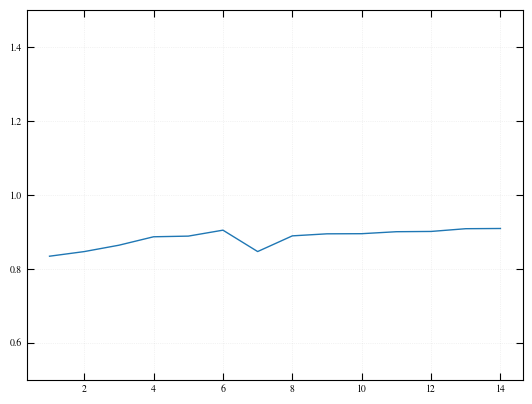

In [52]:
plt.plot(np.linspace(1,14,14),sigma/np.std(white_noise+red_noise))
plt.ylim([0.5,1.5])

In [49]:
# Denoising
noise_floor = 4*0.1 #units of BI
wavy_stuff, denoised_cwt = two.denoise_2d(cwt_result,white_noise_level=noise_floor,sMAD_threshold=3)

initial noise 0.09997693606035617
derived noise 0.11255382126327947


Text(0.03, 0.94, 'c')

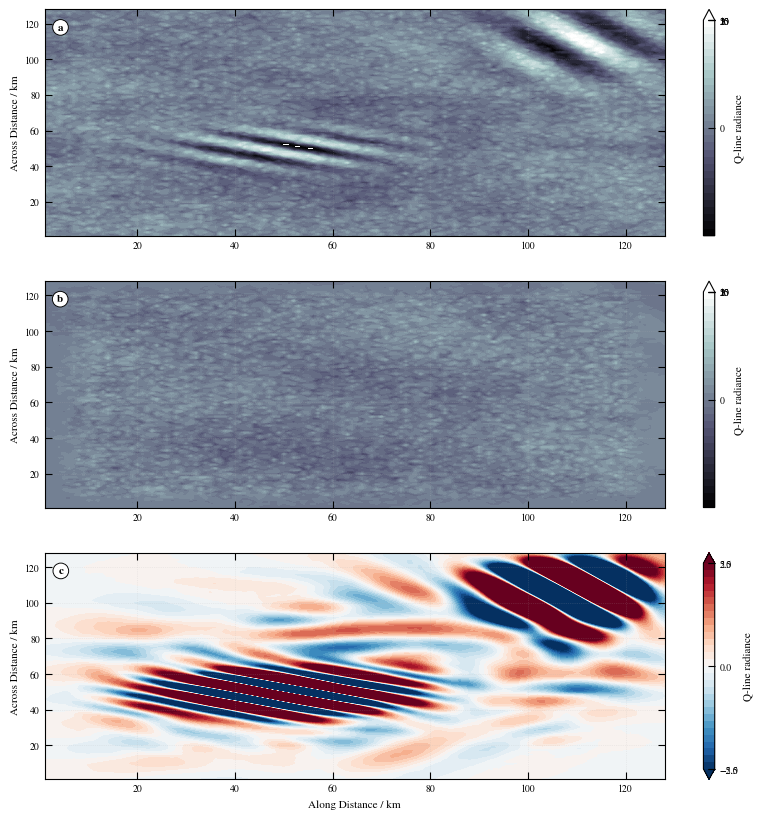

In [50]:
BI_lev = np.linspace(-1,1,31)
fig = plt.figure(figsize=(10,10))
ax1 = fig.add_subplot(311)
plot_orig = ax1.contourf(x,y,orig,levels=BI_lev,extend='max',cmap='bone')
cbar = fig.colorbar(plot_orig,ticks=[0,5,10,15,20],label='Q-line radiance')

ax2 = fig.add_subplot(312)
plot_dirt = ax2.contourf(x,y,BI_low+signal-wavy_stuff+np.mean(orig),levels=BI_lev,extend='max',cmap='bone')
cbar = fig.colorbar(plot_dirt,ticks=[0,5,10,15,20],label='Q-line radiance')

ax3 = fig.add_subplot(313)
plot_wave = ax3.contourf(x,y,wavy_stuff,levels=np.linspace(-0.1,0.1,31),extend='both',cmap='RdBu_r')
cbar = fig.colorbar(plot_wave,ticks=[-5,-2.5,0,2.5,5],label='Q-line radiance')

print('initial noise', np.std(white_noise))
print('derived noise', np.std(signal[13:-13,13:-13]-wavy_stuff[13:-13,13:-13]))

ax3.set_xlabel('Along Distance / km')
ax1.set_ylabel('Across Distance / km')
ax2.set_ylabel('Across Distance / km')
ax3.set_ylabel('Across Distance / km')

letterbox = {"boxstyle": "circle","lw": 0.67,"facecolor": "white","edgecolor": "black"}
ax1.text(0.03,0.94,'a',transform=ax1.transAxes, bbox=letterbox, verticalalignment="top", horizontalalignment="right", weight="bold") 
ax2.text(0.03,0.94,'b',transform=ax2.transAxes, bbox=letterbox, verticalalignment="top", horizontalalignment="right", weight="bold") 
ax3.text(0.03,0.94,'c',transform=ax3.transAxes, bbox=letterbox, verticalalignment="top", horizontalalignment="right", weight="bold") 

#plt.savefig('./figures/2D_example_AWE_BG_removal.png',dpi=300,bbox_inches="tight",pad_inches=0.02)

In [53]:
#noise = np.random.normal(0,noise_floor,(nx,ny))
#noise_cwt = transform.decompose2d(noise, dx, dy, s0*min([dx,dy]), dj, js, jt, aspect=1, opts={'param': 2*np.pi}, mode='scaled', dtype=np.complex128)
#a, b, noise_WAS = two.fit_power_law(noise_cwt['scale'],np.mean(np.abs(noise_cwt['decomposition']),axis=(1,2,3)))

WAS        = np.abs(denoised_cwt['decomposition'])
median_WAS = np.median(WAS, axis=(1,2,3), keepdims=True)
abs_dev    = np.abs(WAS - median_WAS)
sMAD_WAS   = 1.4826 * np.median(abs_dev, axis=(1,2,3), keepdims=True)
# avoid division by zero
sMAD_WAS[sMAD_WAS == 0] = np.finfo(WAS.dtype).eps
WAS_normed = (WAS - median_WAS) / sMAD_WAS
#sMAD_mask  = WAS_normed < sMAD_threshold
#dec[sMAD_mask] = 0

seg_v1 = two.wavefield_segmentation_2d(WAS_normed,3,connectivity_order=2)
print('Identified', np.max(seg_v1), 'initial wave packets!')

WP_labels      = np.arange(1,np.max(seg_v1)+1)
eps = np.abs(np.diff(np.log(2*np.pi/denoised_cwt['period'])))[0]
_, cluster_labels = two.find_clusters_in_freq_theta_numba(denoised_cwt, seg_v1, eps=eps)

cluster_map    = two.build_cluster_map_with_noise(WP_labels,cluster_labels)
seg_v2         = two.relabel_by_xy_overlap(seg_v1, cluster_map)
print('Reduced the number of wave packets to', np.max(seg_v2))

seg_v3         = two.variance_filter(denoised_cwt, seg_v2, var_threshold=0.99)
print('Final number of wave packets:', np.max(seg_v3))

Identified 35 initial wave packets!
suggested scaling: 0.5791684504007101
Reduced the number of wave packets to 25
Final number of wave packets: 2


In [9]:
two.compute_label_extents(seg_v1)

(array([128,  30,  81]),
 array([ -1,  69, 127]),
 array([128,  25,  83]),
 array([ -1,  73, 127]),
 array([False,  True,  True]))

In [54]:
recon_WP, amp_WP, k_across_WP, k_along_WP = two.recon_allWP_2d(denoised_cwt, seg_v3)

100%|██████████| 16384/16384 [00:00<00:00, 30402.61it/s]


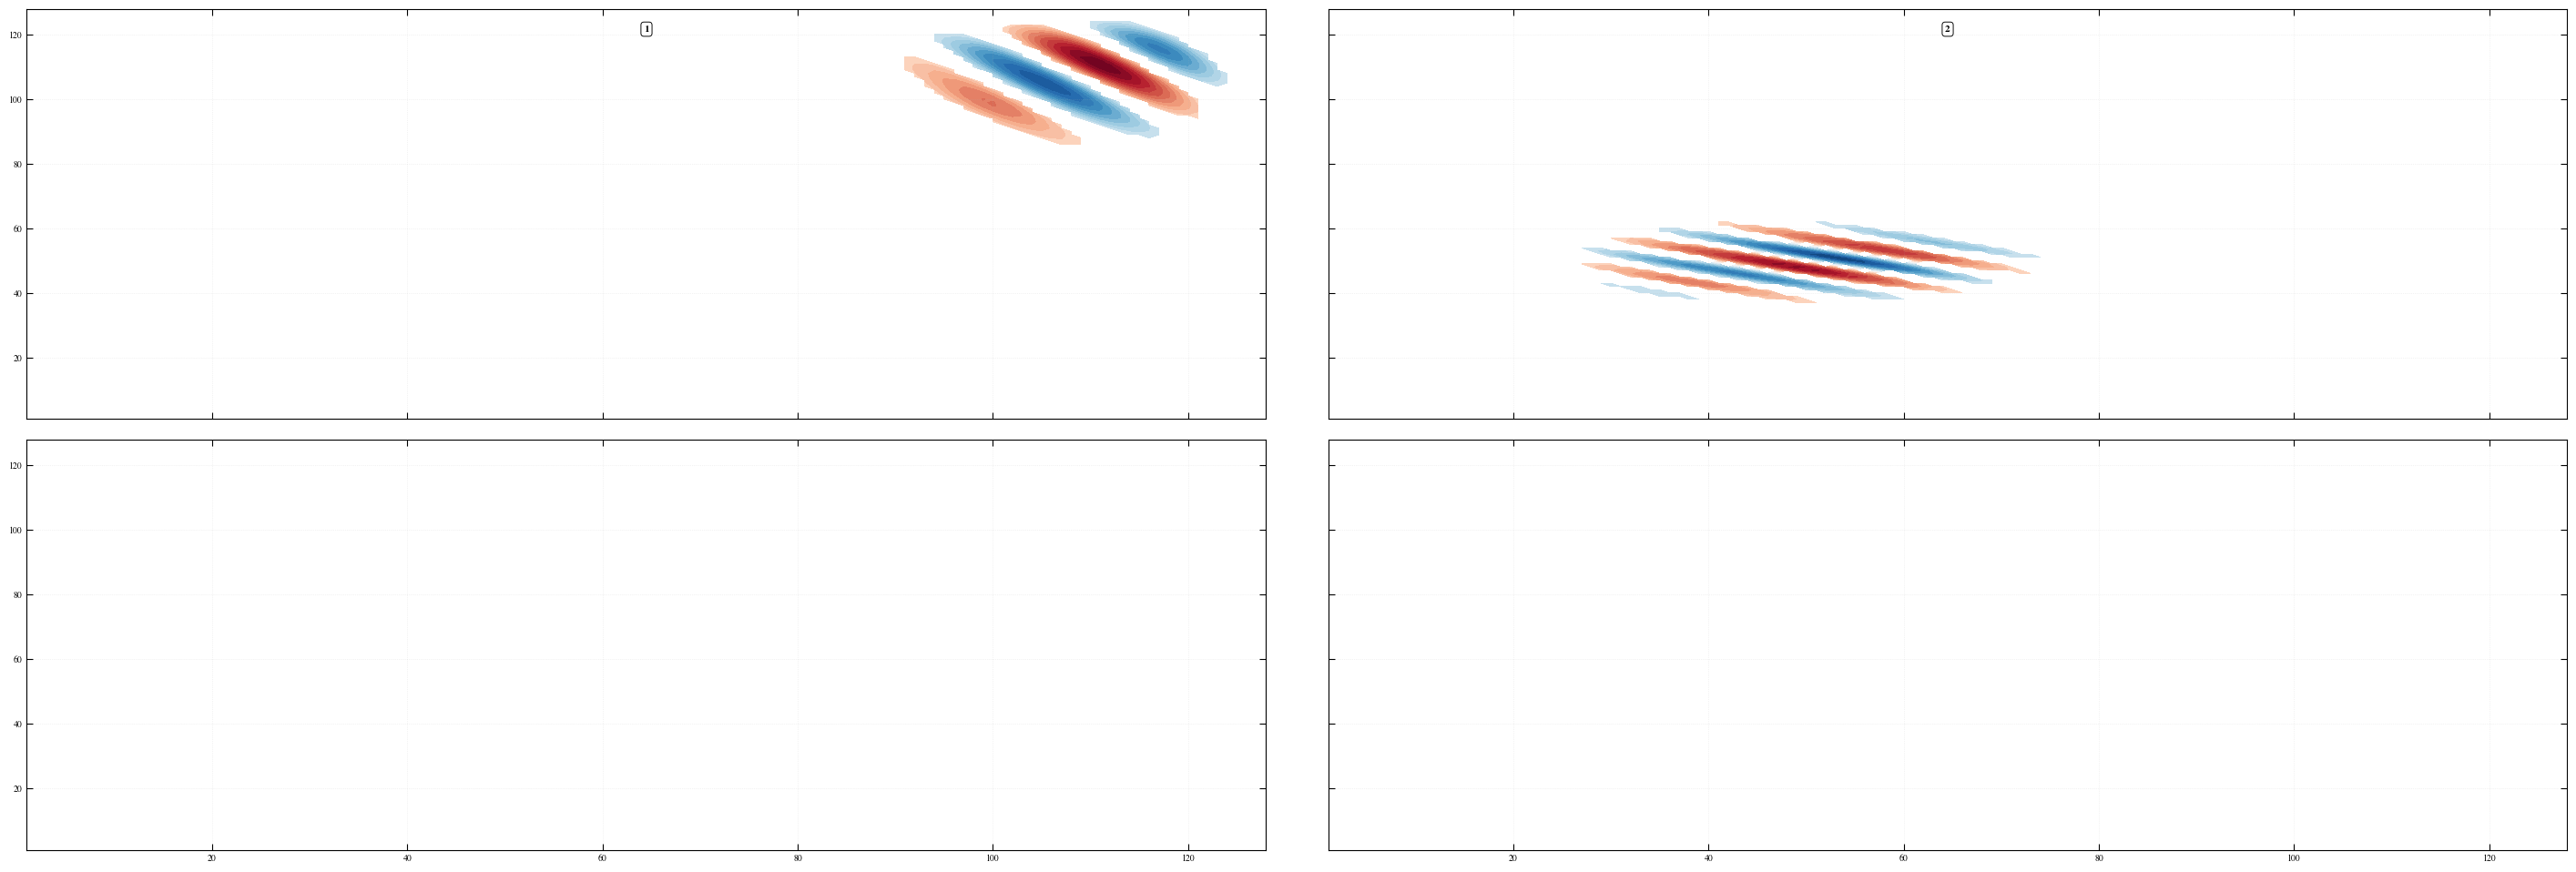

In [55]:
#Mit dj = 1/8 / sMAD_threshold = 3 / prominence=3 / sMAD_threshold=3 / eps=0.18 / dj = 1/8
import matplotlib.colors as mcolors
rad_lev=np.linspace(-1,1,31)
row, col = pt.define_figgrid(3)#recon_WP.shape[0])
gskw = {"hspace": 0.05, "wspace": 0.05, "width_ratios": col*[1], "height_ratios": row*[1]}

fig, ax=plt.subplots(row,col, figsize=(36,12), gridspec_kw=gskw,sharex=True, sharey=True)

for i in range(row):
    for j in range(col):
        if i*col+j < recon_WP.shape[0]:
            masked = np.ma.masked_inside(recon_WP[i*col+j,:,:], -0.2, 0.2)  
            norm = mcolors.TwoSlopeNorm(vmin=rad_lev[0], vcenter=0.0, vmax=rad_lev[-1])
            ax[i,j].contourf(x,y,masked,levels=rad_lev,cmap="RdBu_r",norm=norm,extend='both')
            ax[i,j].text(0.5, 0.95, str(i*col+j+1), verticalalignment='center', horizontalalignment='center', transform=ax[i,j].transAxes, 
                                    weight='bold', bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})

In [17]:
WAS = np.abs(denoised_cwt["decomposition"])
wavelength  = 2 * np.pi / denoised_cwt["period"]
orientation = denoised_cwt["theta"]
labels, k_seg, theta_seg = two.segments2points_numba(WAS, wavelength, orientation, seg_v1)
labels_3, k_seg_3, theta_seg_3 = two.segments2points_numba(WAS, wavelength, orientation, seg_v3)

Text(0.5, 0, 'log(k)')

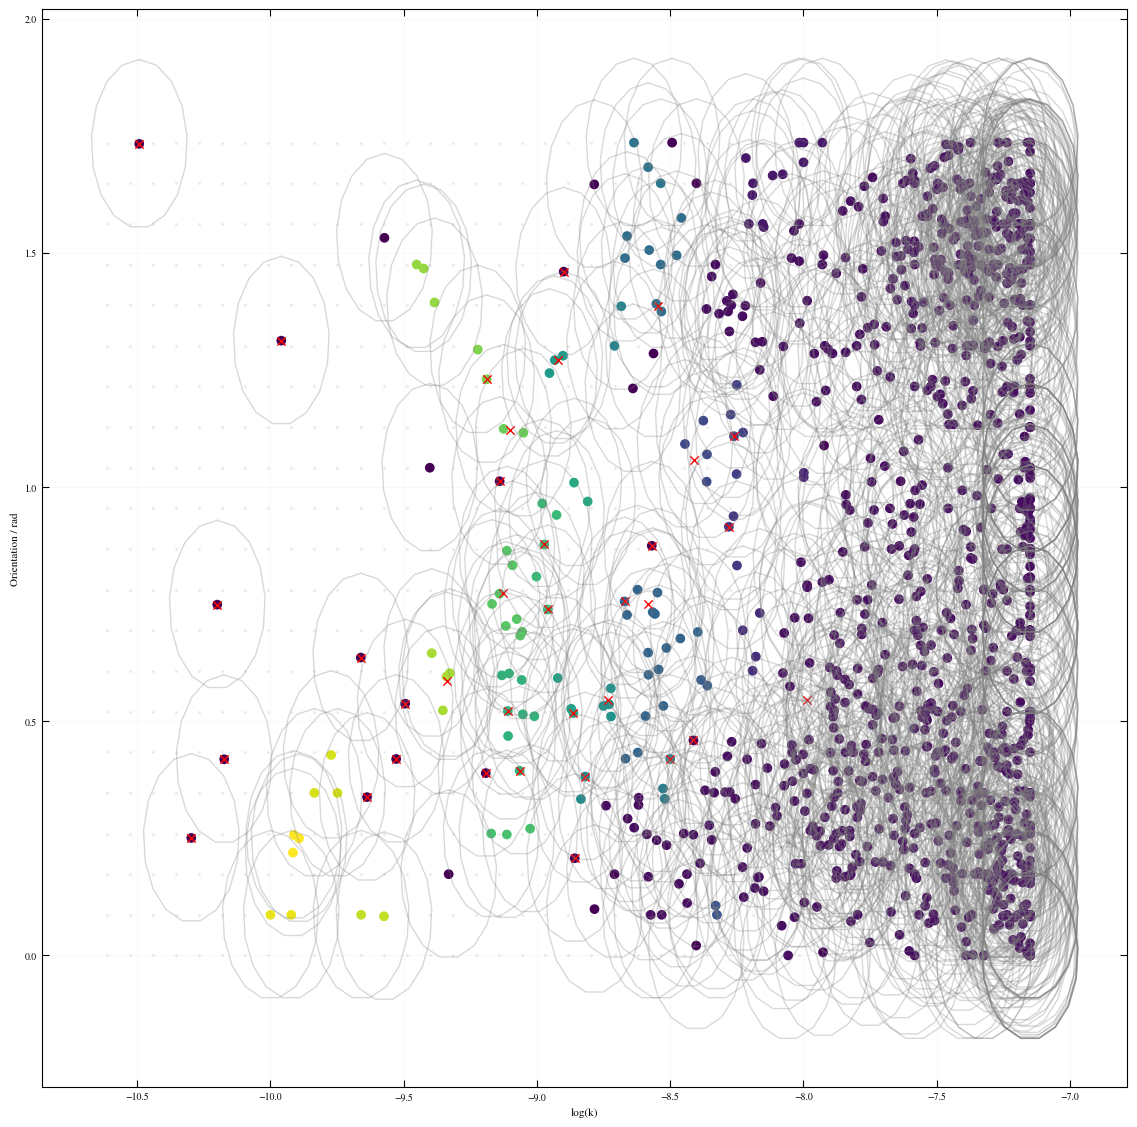

In [18]:
# NO EXECUTION NEEDED
a = denoised_cwt['period']
b = denoised_cwt['theta']

fig = plt.figure(figsize=(14,14))
for ia in a:
    for ib in b:
        plt.scatter(np.log(2*np.pi/ia),0.58*ib,color='grey',alpha=0.1,s=2)

ang=np.linspace(0,2*np.pi,18)
for i in range(len(k_seg)):
    plt.plot(np.log(k_seg[i])+0.18*np.sin(ang),0.58*theta_seg[i]+0.18*np.cos(ang),color='grey',alpha=0.3)
#for idx, label in enumerate(WP_labels):
    #mask = amp_seg[idx,:,:] > 0
plt.scatter(np.log(k_seg),0.58*theta_seg,c=cluster_labels)
plt.scatter(np.log(k_seg_3),0.58*theta_seg_3,marker='x',c='red')
    #plt.text(np.log(np.median(2*np.pi/lh_seg[idx,:,:][mask])),np.median(th_seg[idx,:,:][mask]),str(label))

#plt.ylim([0,np.pi])
plt.ylabel('Orientation / rad')
plt.xlabel('log(k)')